# Pair-by-Pair Analysis: Baseline vs RAG Outputs

Interactive analysis of experiments-4.jsonl comparing baseline and RAG-augmented code generation for each HumanEval task.

In [7]:
# Load experiments-4.jsonl data
import json
from pathlib import Path

experiments_file = Path("experiments-4.jsonl")

# Load all tasks
tasks = []
with open(experiments_file, 'r') as f:
    for line in f:
        tasks.append(json.loads(line))

print(f"Loaded {len(tasks)} HumanEval tasks")
print(f"Task IDs: {[t['task_id'] for t in tasks]}")

Loaded 30 HumanEval tasks
Task IDs: ['HumanEval/0', 'HumanEval/1', 'HumanEval/2', 'HumanEval/3', 'HumanEval/4', 'HumanEval/5', 'HumanEval/6', 'HumanEval/7', 'HumanEval/8', 'HumanEval/9', 'HumanEval/10', 'HumanEval/11', 'HumanEval/12', 'HumanEval/13', 'HumanEval/14', 'HumanEval/15', 'HumanEval/16', 'HumanEval/17', 'HumanEval/18', 'HumanEval/19', 'HumanEval/20', 'HumanEval/21', 'HumanEval/22', 'HumanEval/23', 'HumanEval/24', 'HumanEval/25', 'HumanEval/26', 'HumanEval/27', 'HumanEval/28', 'HumanEval/29']


In [8]:
# Task comparison function
def compare_task(task_idx):
    """Display baseline vs RAG comparison for a single task"""
    task = tasks[task_idx]
    
    print("="*100)
    print(f"TASK: {task['task_id']}")
    print("="*100)
    
    print("\n📋 PROBLEM STATEMENT:")
    print("-"*100)
    print(task['prompt'])
    
    print("\n" + "="*100)
    print("⚙️  RAG METRICS")
    print("="*100)
    metrics = task['rag_metrics']
    print(f"  • Triggers: {metrics['triggers']}")
    print(f"  • Avg Δ Entropy: {metrics['avg_delta_entropy']:.4f}")
    print(f"  • Avg Latency: {metrics['avg_intervention_latency_ms']:.2f} ms")
    print(f"  • Entropy History Length: {len(metrics['entropy_history'])} tokens")
    
    print("\n" + "="*100)
    print("🔵 BASELINE OUTPUT (No RAG)")
    print("="*100)
    print(task['baseline_output'])
    
    print("\n" + "="*100)
    print("🟢 RAG OUTPUT (With Adaptive Retrieval)")
    print("="*100)
    print(task['rag_output'])
    
    print("\n" + "="*100)
    
# Display first task
compare_task(0)

TASK: HumanEval/0

📋 PROBLEM STATEMENT:
----------------------------------------------------------------------------------------------------
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)
    True
    """


⚙️  RAG METRICS
  • Triggers: 1
  • Avg Δ Entropy: 2.2812
  • Avg Latency: 1436.30 ms
  • Entropy History Length: 471 tokens

🔵 BASELINE OUTPUT (No RAG)
To solve the problem of checking if any two numbers in a list are closer to each other than a given threshold, we can use a simple approach that involves sorting the list and then checking adjacent elements for closeness. Here's how you can implement this:

```python
from typing import List

def has_close_elements(numbers: List[float], threshold: float) 

## Interactive Navigation

Use the cells below to navigate through tasks one by one.

In [9]:
# Navigate: Change task_idx to view different tasks (0 to len(tasks)-1)
task_idx = 3  # Change this number to see different tasks

compare_task(task_idx)

TASK: HumanEval/3

📋 PROBLEM STATEMENT:
----------------------------------------------------------------------------------------------------
from typing import List


def below_zero(operations: List[int]) -> bool:
    """ You're given a list of deposit and withdrawal operations on a bank account that starts with
    zero balance. Your task is to detect if at any point the balance of account fallls below zero, and
    at that point function should return True. Otherwise it should return False.
    >>> below_zero([1, 2, 3])
    False
    >>> below_zero([1, 2, -4, 5])
    True
    """


⚙️  RAG METRICS
  • Triggers: 0
  • Avg Δ Entropy: 0.0000
  • Avg Latency: 0.00 ms
  • Entropy History Length: 396 tokens

🔵 BASELINE OUTPUT (No RAG)
To solve this problem, we need to iterate through the list of operations and keep track of the current balance. If at any point the balance falls below zero, we should return `True`. If we finish iterating through the list without the balance going below zero

## Entropy Visualization: Baseline vs RAG

Visualize entropy trajectories to see where RAG interventions occurred.

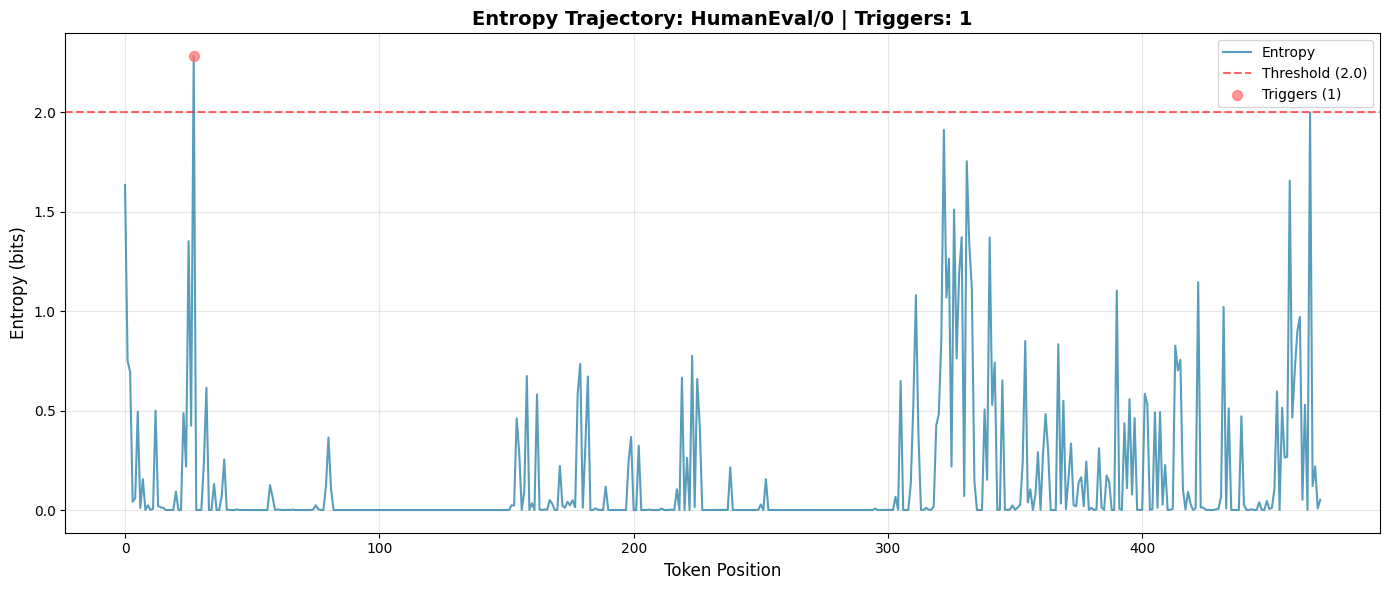

Entropy Statistics for HumanEval/0:
  • Mean: 0.1474
  • Std Dev: 0.3351
  • Max: 2.2812
  • Min: -0.0000
  • Points above threshold: 1 / 471


In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_entropy_comparison(task_idx):
    """Plot entropy history for a specific task"""
    task = tasks[task_idx]
    entropy_history = task['rag_metrics']['entropy_history']
    triggers = task['rag_metrics']['triggers']
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot entropy trajectory
    tokens = np.arange(len(entropy_history))
    ax.plot(tokens, entropy_history, color='#2E86AB', linewidth=1.5, alpha=0.8, label='Entropy')
    
    # Add threshold line
    threshold = 2.0  # Hardcoded from copilot-instructions.md
    ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.6, label=f'Threshold ({threshold})')
    
    # Highlight trigger points (where entropy > threshold)
    trigger_points = [i for i, h in enumerate(entropy_history) if h > threshold]
    if trigger_points:
        ax.scatter(trigger_points, [entropy_history[i] for i in trigger_points], 
                  color='#FF6B6B', s=50, zorder=5, alpha=0.7, label=f'Triggers ({len(trigger_points)})')
    
    ax.set_xlabel('Token Position', fontsize=12)
    ax.set_ylabel('Entropy (bits)', fontsize=12)
    ax.set_title(f'Entropy Trajectory: {task["task_id"]} | Triggers: {triggers}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Entropy Statistics for {task['task_id']}:")
    print(f"  • Mean: {np.mean(entropy_history):.4f}")
    print(f"  • Std Dev: {np.std(entropy_history):.4f}")
    print(f"  • Max: {np.max(entropy_history):.4f}")
    print(f"  • Min: {np.min(entropy_history):.4f}")
    print(f"  • Points above threshold: {len(trigger_points)} / {len(entropy_history)}")

# Plot entropy for first task
plot_entropy_comparison(0)

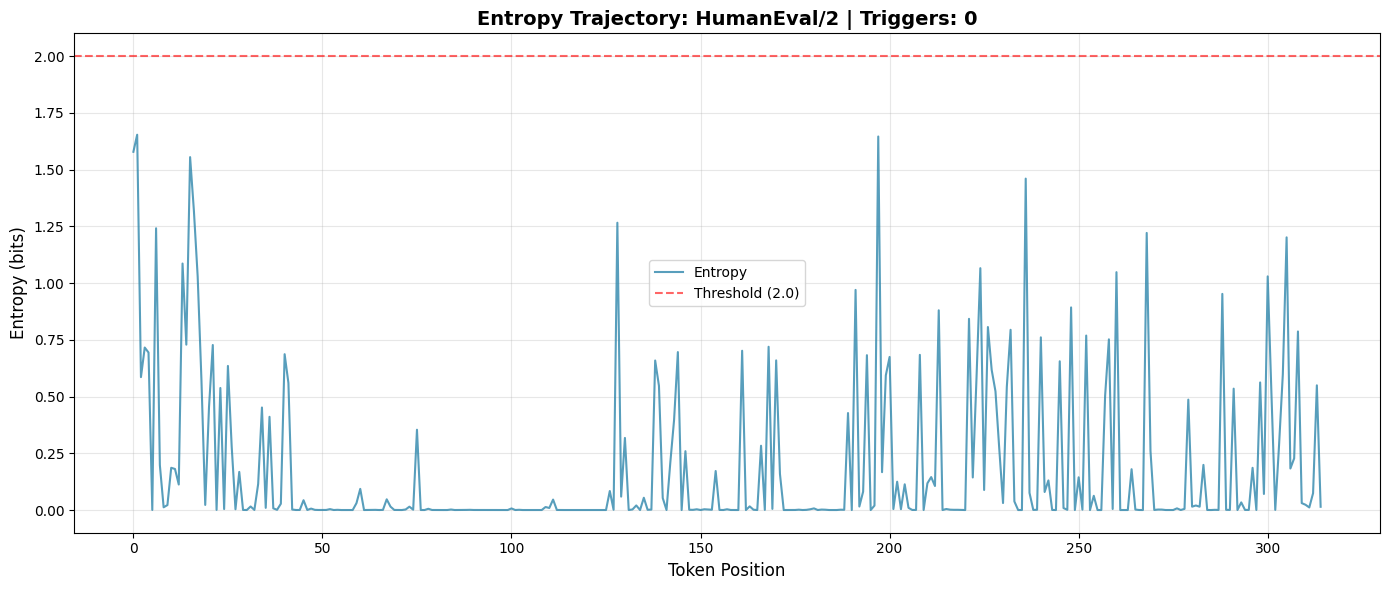

Entropy Statistics for HumanEval/2:
  • Mean: 0.1845
  • Std Dev: 0.3450
  • Max: 1.6533
  • Min: -0.0000
  • Points above threshold: 0 / 315


In [11]:
# Interactive entropy plot - change task_idx to visualize different tasks
task_idx = 2  # Change this number

plot_entropy_comparison(task_idx)

## Summary: All Tasks Overview

Compare key metrics across all tasks.

In [12]:
import pandas as pd

# Create summary DataFrame
summary_data = []
for task in tasks:
    metrics = task['rag_metrics']
    summary_data.append({
        'Task ID': task['task_id'],
        'Triggers': metrics['triggers'],
        'Avg Δ Entropy': metrics['avg_delta_entropy'],
        'Avg Latency (ms)': metrics['avg_intervention_latency_ms'],
        'Tokens': len(metrics['entropy_history']),
        'Mean Entropy': np.mean(metrics['entropy_history']),
        'Max Entropy': np.max(metrics['entropy_history'])
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY: All Tasks")
print("="*100)
print(summary_df.to_string(index=False))

# Additional statistics
print("\n" + "="*100)
print("AGGREGATE STATISTICS")
print("="*100)
print(f"Total tasks: {len(tasks)}")
print(f"Tasks with triggers: {(summary_df['Triggers'] > 0).sum()}")
print(f"Tasks without triggers: {(summary_df['Triggers'] == 0).sum()}")
print(f"Average triggers per task: {summary_df['Triggers'].mean():.2f}")
print(f"Max triggers in a single task: {summary_df['Triggers'].max()}")
print(f"Average Δ entropy (when triggered): {summary_df[summary_df['Triggers'] > 0]['Avg Δ Entropy'].mean():.4f}")


SUMMARY: All Tasks
     Task ID  Triggers  Avg Δ Entropy  Avg Latency (ms)  Tokens  Mean Entropy  Max Entropy
 HumanEval/0         1       2.281173       1436.303377     471      0.147403     2.281250
 HumanEval/1         5       1.658251       1981.081820     460      0.324573     3.062500
 HumanEval/2         0       0.000000          0.000000     315      0.184529     1.653320
 HumanEval/3         0       0.000000          0.000000     396      0.134842     1.632812
 HumanEval/4         0       0.000000          0.000000     403      0.122747     1.798828
 HumanEval/5         0       0.000000          0.000000     420      0.187346     1.923828
 HumanEval/6         0       0.000000          0.000000     636      0.128767     1.570312
 HumanEval/7         3       1.348606       1457.493226     211      0.369303     3.125000
 HumanEval/8         0       0.000000          0.000000     366      0.184822     1.943359
 HumanEval/9         0       0.000000          0.000000     429      0

## Pass/Fail Impact Analysis

Let's evaluate the generated code against the unit tests, identifying precisely which tasks were fixed by RAG, and which regressed.

In [13]:
import re
import io
import contextlib
import textwrap
from copy import deepcopy

def extract_imports(text: str) -> str:
    """Extract standard Python import statements from generated text."""
    imports = re.findall(r'^(?:from\s+\w+.*|import\s+\w+.*)', text, re.MULTILINE)
    return '\n'.join(sorted(list(set(imports)))) + '\n'

def extract_python_code(text: str) -> str:
    """Clean generated text to extract only executable Python code bodies."""
    # 1. Look for markdown code blocks
    match = re.search(r'```python\n(.*?)\n```', text, re.DOTALL)
    if match:
        code = match.group(1)
    else:
        # 2. Look for the start of function definitions
        match = re.search(r'(def\s+.*)', text, re.DOTALL)
        code = match.group(1) if match else text

    lines = code.split('\n')
    clean_lines = []
    
    # 3. Handle stop sequences like prints or comments
    for line in lines:
        stripped = line.strip()
        if stripped.startswith("print(") or stripped.startswith("# Example") or stripped.startswith("### Expl"):
            break
        clean_lines.append(line)
        
    code_body = '\n'.join(clean_lines)
    
    # 4. Correct indentation (Critical Fix)
    if code_body and not code_body.startswith("def") and not code_body.startswith("    "):
        code_body = textwrap.indent(code_body, "    ")
        
    return code_body

def evaluate_code(code: str, test_cases: str) -> bool:
    """Execute code in a sandbox environment and return success boolean."""
    if not code: return False
    global_ns = {}
    with contextlib.redirect_stdout(io.StringIO()):
        try:
            exec(code, global_ns)
            exec(test_cases, global_ns)
            return True
        except Exception:
            return False

# Evaluate each task
results_with_impact = []
for idx, task in enumerate(tasks):
    # Baseline
    imp_b = extract_imports(task['baseline_output'])
    body_b = extract_python_code(task['baseline_output'])
    full_code_b = f"{imp_b}\n{task['prompt']}\n{body_b}"
    b_pass = evaluate_code(full_code_b, task['test_cases'])
    
    # RAG
    imp_r = extract_imports(task['rag_output'])
    body_r = extract_python_code(task['rag_output'])
    full_code_r = f"{imp_r}\n{task['prompt']}\n{body_r}"
    r_pass = evaluate_code(full_code_r, task['test_cases'])
    
    status = "Stable (Both Passed)"
    if r_pass and not b_pass:
        status = "💡 CORRECTED BY RAG"
    elif not r_pass and b_pass:
        status = "⚠️ RAG REGRESSION"
    elif not r_pass and not b_pass:
        status = "Critical Failure (Both)"
        
    results_with_impact.append({
        'Index': idx,
        'Task ID': task['task_id'],
        'Baseline Pass': b_pass,
        'RAG Pass': r_pass,
        'Status': status,
        'Triggers': task['rag_metrics']['triggers'],
        'Avg Δ Entropy': task['rag_metrics']['avg_delta_entropy'],
    })

impact_df = pd.DataFrame(results_with_impact)

print("="*80)
print("EVALUATION IMPACT SUMMARY")
print("="*80)
print(impact_df['Status'].value_counts())
print("\n" + "="*80)
print("TASKS CORRECTED BY RAG (Task indices to analyze!)")
print("="*80)
corrected_df = impact_df[impact_df['Status'] == "💡 CORRECTED BY RAG"]
if not corrected_df.empty:
    print(corrected_df[['Index', 'Task ID', 'Triggers', 'Avg Δ Entropy']].to_string(index=False))
else:
    print("No tasks were corrected by RAG in this dataset.")
    
print("\n" + "="*80)
print("TASKS WHERE RAG REGRESSED")
print("="*80)
regressed_df = impact_df[impact_df['Status'] == "⚠️ RAG REGRESSION"]
if not regressed_df.empty:
    print(regressed_df[['Index', 'Task ID', 'Triggers', 'Avg Δ Entropy']].to_string(index=False))
else:
    print("No tasks regressed due to RAG.")

EVALUATION IMPACT SUMMARY
Status
Stable (Both Passed)    28
💡 CORRECTED BY RAG       2
Name: count, dtype: int64

TASKS CORRECTED BY RAG (Task indices to analyze!)
 Index      Task ID  Triggers  Avg Δ Entropy
     7  HumanEval/7         3       1.348606
    29 HumanEval/29         6       2.232617

TASKS WHERE RAG REGRESSED
No tasks regressed due to RAG.


In [17]:
import json
import re
import io
import contextlib
import textwrap

def evaluate_code(code: str, test_cases: str) -> bool:
    if not code: return False
    global_ns = {}
    with contextlib.redirect_stdout(io.StringIO()):
        try:
            exec(code, global_ns)
            exec(test_cases, global_ns)
            return True
        except Exception:
            return False

with open('experiments-4.jsonl', 'r') as f:
    tasks = [json.loads(line) for line in f]

stats = {
    'total': len(tasks),
    'b_pass_r_pass': 0,
    'b_pass_r_fail': 0,
    'b_fail_r_pass': 0,
    'b_fail_r_fail': 0,
}

for idx in range(len(tasks)):
    task = tasks[idx]
    
    imp_b = extract_imports(task['baseline_output'])
    body_b = extract_python_code(task['baseline_output'])
    b_pass = evaluate_code(f"{imp_b}\n{task['prompt']}\n{body_b}", task['test_cases'])
    
    imp_r = extract_imports(task['rag_output'])
    body_r = extract_python_code(task['rag_output'])
    r_pass = evaluate_code(f"{imp_r}\n{task['prompt']}\n{body_r}", task['test_cases'])
    
    if b_pass and r_pass:
        stats['b_pass_r_pass'] += 1
    elif b_pass and not r_pass:
        stats['b_pass_r_fail'] += 1
    elif not b_pass and r_pass:
        stats['b_fail_r_pass'] += 1
    elif not b_pass and not r_pass:
        stats['b_fail_r_fail'] += 1

print("=== MATRIZ DE CONFUSIÓN DE EFECTIVIDAD (BASELINE VS RAG) ===")
print("Total Tareas Evaluadas:", stats['total'])
print(f"Baseline WIN  & RAG WIN : {stats['b_pass_r_pass']}")
print(f"Baseline WIN  & RAG FAIL: {stats['b_pass_r_fail']} (Regresiones destructivas)")
print(f"Baseline FAIL & RAG WIN : {stats['b_fail_r_pass']} (Mejoras por Ghost Prompting)")
print(f"Baseline FAIL & RAG FAIL: {stats['b_fail_r_fail']}")

=== MATRIZ DE CONFUSIÓN DE EFECTIVIDAD (BASELINE VS RAG) ===
Total Tareas Evaluadas: 30
Baseline WIN  & RAG WIN : 28
Baseline WIN  & RAG FAIL: 0 (Regresiones destructivas)
Baseline FAIL & RAG WIN : 2 (Mejoras por Ghost Prompting)
Baseline FAIL & RAG FAIL: 0


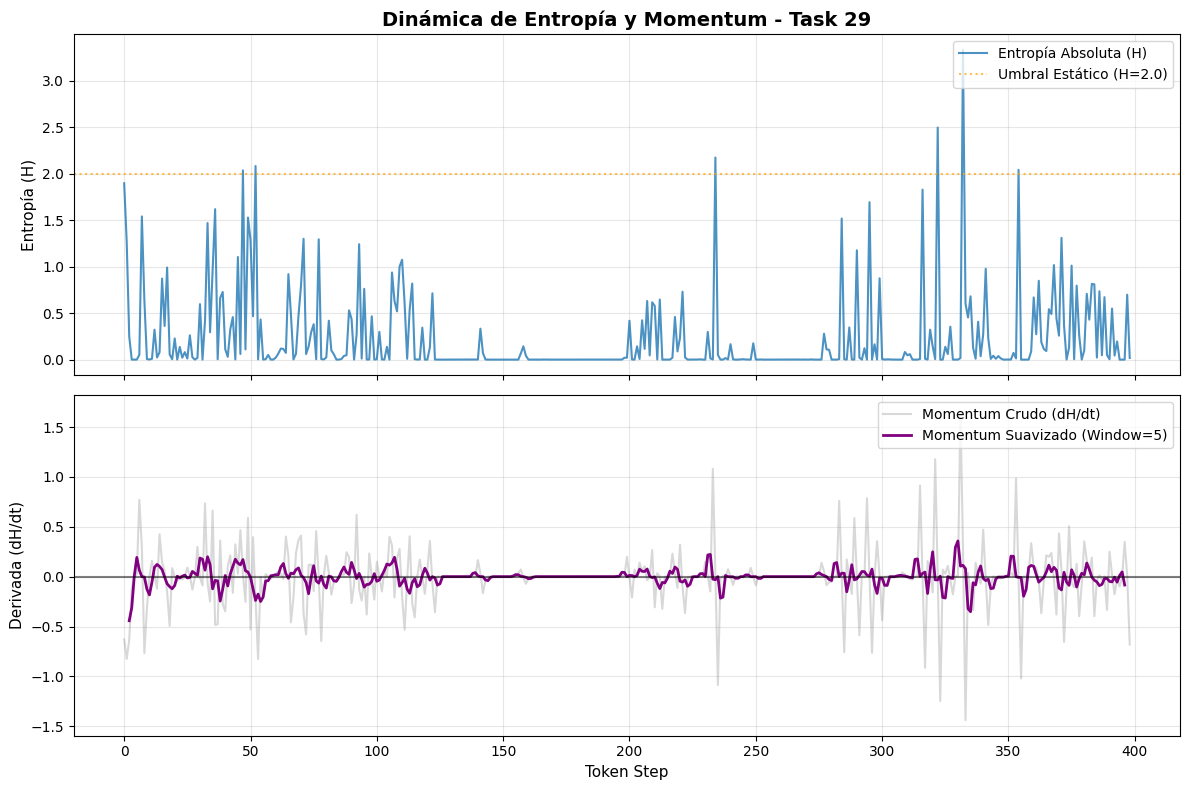

In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el dataset
with open('experiments-4.jsonl', 'r') as f:
    tasks = [json.loads(line) for line in f]

# Usamos la Task 29 que sabemos que es nuestro caso de éxito (Modality Shift)
task_idx = 29
task = tasks[task_idx]

entropy_history = task.get('rag_metrics', {}).get('entropy_history', [])
trigger_points = task.get('rag_metrics', {}).get('trigger_points', [])

if entropy_history:
    # 2. Cálculos Cinemáticos de la Entropía
    H = np.array(entropy_history)
    
    # Derivada discreta (Tasa de cambio / Momentum)
    dH = np.gradient(H)
    
    # Suavizado para ver la "tendencia de aceleración" eliminando el ruido blanco
    window = 5
    dH_smoothed = pd.Series(dH).rolling(window=window, center=True).mean()

    # 3. Graficar
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Plot 1: Entropía Absoluta (H) ---
    ax1.plot(H, label='Entropía Absoluta (H)', color='#1f77b4', alpha=0.8, linewidth=1.5)
    ax1.axhline(y=2.0, color='orange', linestyle=':', label='Umbral Estático (H=2.0)', alpha=0.7)
    
    for i, t in enumerate(trigger_points):
        label = 'Ghost Prompt Trigger' if i == 0 else ""
        ax1.axvline(x=t, color='red', linestyle='--', alpha=0.6, label=label)
        if t < len(H):
            ax1.scatter(t, H[t], color='red', zorder=5)
            
    ax1.set_ylabel('Entropía (H)', fontsize=11)
    ax1.set_title(f'Dinámica de Entropía y Momentum - Task {task_idx}', fontsize=14, weight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Momentum de la Entropía (dH/dt) ---
    ax2.plot(dH, label='Momentum Crudo (dH/dt)', color='gray', alpha=0.3)
    ax2.plot(dH_smoothed, label=f'Momentum Suavizado (Window={window})', color='purple', linewidth=2)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5) # Línea base 0
    
    for i, t in enumerate(trigger_points):
        ax2.axvline(x=t, color='red', linestyle='--', alpha=0.6)
        
        # Resaltar la zona inmediatamente anterior al trigger (ventana de desestabilización)
        if t - window > 0:
            ax2.axvspan(t - window, t, color='yellow', alpha=0.3, label='Zona de Desestabilización' if i==0 else "")
            
    ax2.set_xlabel('Token Step', fontsize=11)
    ax2.set_ylabel('Derivada (dH/dt)', fontsize=11)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No hay historial de entropía disponible para esta tarea.")

==== ANÁLISIS DE RECUPERACIÓN DE CERTEZA (ΔH) ====
Triggers evaluados en todo el dataset: 21
Entropía promedio en el punto de pánico: 2.236
Entropía promedio en los 5 tokens post-inyección: 0.374
📉 DROP Promedio de Entropía (ΔH): 1.862 (83.3% de reducción)


/tmp/ipykernel_331/337990116.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([entropies_before, entropies_after], patch_artist=True, widths=0.4,


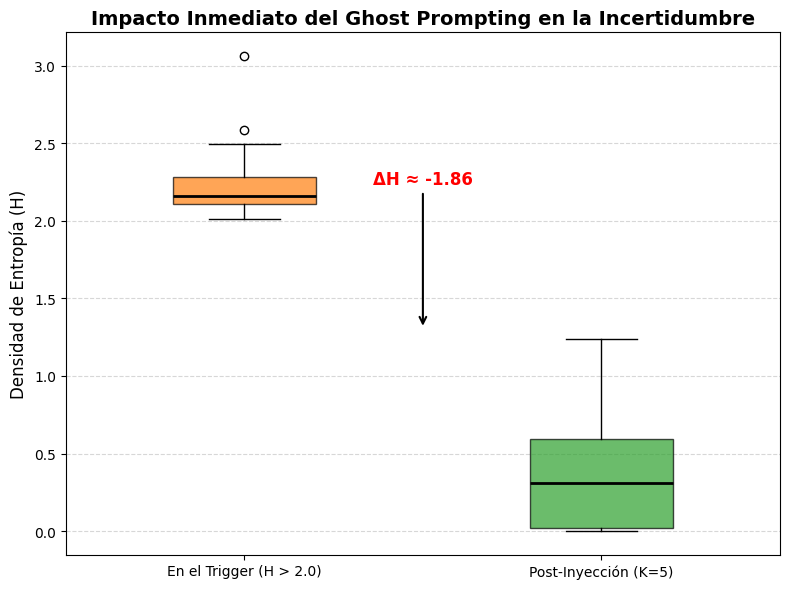

In [20]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
with open('experiments-4.jsonl', 'r') as f:
    tasks = [json.loads(line) for line in f]

# 2. Configurar la extracción de la Caída de Entropía (Delta H)
threshold = 2.0
burst_cooldown = 15 # El modelo genera "bursts" después del trigger y evitamos contar múltiples triggers pegados
k_tokens_after = 5  # Cuántos tokens promediamos justo después de la inyección

drops = []
entropies_before = []
entropies_after = []

for task in tasks:
    history = task.get('rag_metrics', {}).get('entropy_history', [])
    if not history: continue
    
    last_trigger_idx = -burst_cooldown
    
    for i, h in enumerate(history):
        if h > threshold and (i - last_trigger_idx) >= burst_cooldown:
            # ¡Trigger detectado! (Ghost Prompt inyectado)
            
            # Revisar si tenemos suficientes tokens por delante para medir la calma
            if i + k_tokens_after < len(history):
                # La entropía en el momento exacto del pánico
                peak_entropy = h 
                
                # La entropía promedio de los siguientes K tokens (el efecto de la pastilla del RAG)
                avg_entropy_after = np.mean(history[i+1 : i+1+k_tokens_after])
                
                delta_h = peak_entropy - avg_entropy_after
                
                entropies_before.append(peak_entropy)
                entropies_after.append(avg_entropy_after)
                drops.append(delta_h)
            
            last_trigger_idx = i

# 3. Métricas Macro
print("==== ANÁLISIS DE RECUPERACIÓN DE CERTEZA (ΔH) ====")
print(f"Triggers evaluados en todo el dataset: {len(drops)}")
print(f"Entropía promedio en el punto de pánico: {np.mean(entropies_before):.3f}")
print(f"Entropía promedio en los {k_tokens_after} tokens post-inyección: {np.mean(entropies_after):.3f}")
print(f"📉 DROP Promedio de Entropía (ΔH): {np.mean(drops):.3f} ({ (np.mean(drops) / np.mean(entropies_before))*100 :.1f}% de reducción)")

# 4. Gráfico para el Paper: Boxplot del Efecto de la Inyección
plt.figure(figsize=(8, 6))
box = plt.boxplot([entropies_before, entropies_after], patch_artist=True, widths=0.4,
                  labels=['En el Trigger (H > 2.0)', f'Post-Inyección (K={k_tokens_after})'])

# Estilos
colors = ['#ff7f0e', '#2ca02c']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    
for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

plt.title('Impacto Inmediato del Ghost Prompting en la Incertidumbre', fontsize=14, weight='bold')
plt.ylabel('Densidad de Entropía (H)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Anotación de la caída
mean_before = np.mean(entropies_before)
mean_after = np.mean(entropies_after)
plt.annotate(f'ΔH ≈ -{np.mean(drops):.2f}', 
             xy=(1.5, (mean_before + mean_after)/2), 
             xytext=(1.5, mean_before),
             arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
             fontsize=12, weight='bold', ha='center', color='red')

plt.tight_layout()
plt.show()